# 1.

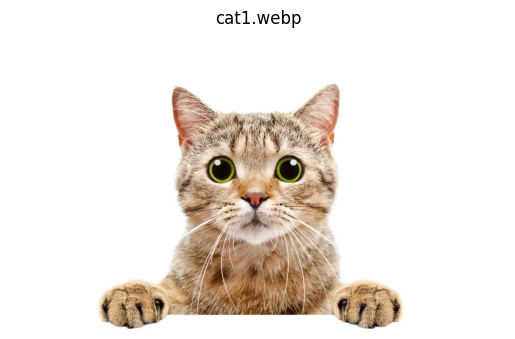

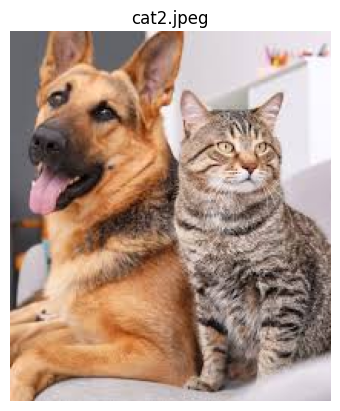

In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


def show_img(img, title=None):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


image_dir = Path.cwd() / 'Cat_detection' / 'Cat_detection'
cascade_dir = image_dir / 'Cat_detection'
img_paths = [
    image_dir / 'cat1.webp',
    image_dir / 'cat2.jpeg',
]

images = []
for path in img_paths:
    if path.exists():
        img = cv2.imread(str(path))
        if img is None:
            print(f"Failed to read image: {path}")
            continue
        images.append(img)
        show_img(img, title=str(path.name))
    else:

        print(f"Image not found: {path}")



# 2.

Cascade loaded: True
Cascade file exists: True


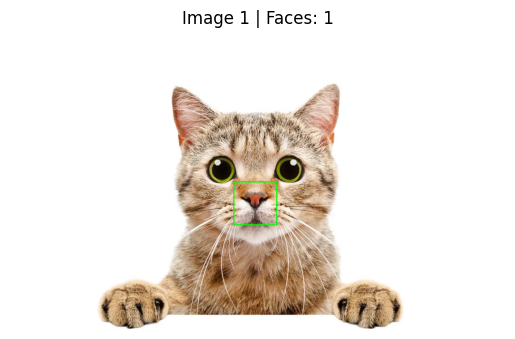

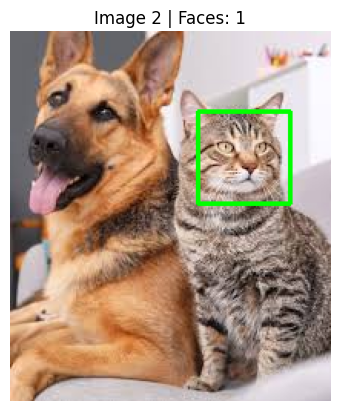

In [20]:

cascade_path = cascade_dir / 'haarcascade_frontalcatface_extended.xml'
cat_cascade = cv2.CascadeClassifier(str(cascade_path))
print(f"Cascade loaded: {not cat_cascade.empty()}")
print(f"Cascade file exists: {cascade_path.exists()}")


def detect_and_show(img, cascade, title=None):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(50, 50))
    img_out = img.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(img_out, (x, y), (x + w, y + h), (0, 255, 0), 2)
    show_img(img_out, title=title + f' | Faces: {len(faces)}')
    return faces



for idx, img in enumerate(images): 
    detect_and_show(img, cat_cascade, title=f'Image {idx+1}')

# 3.

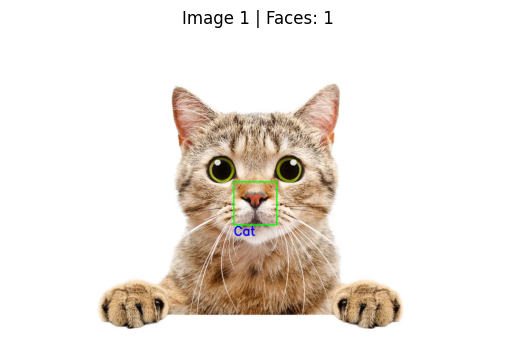

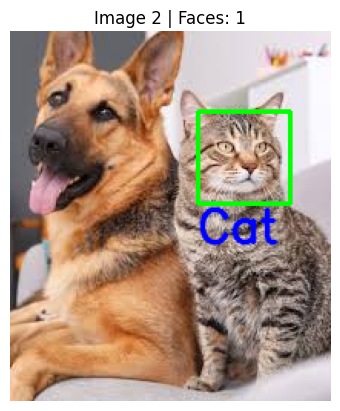

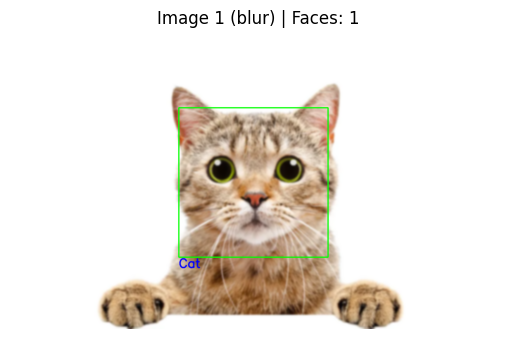

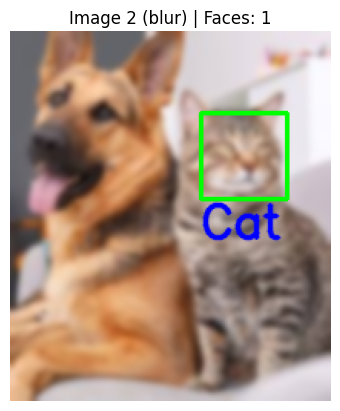

In [21]:

def detect_draw_text(img, cascade, title=None, blur=False):
    proc_img = img.copy()
    if blur:
        proc_img = cv2.GaussianBlur(proc_img, (11, 11), 0)
    gray = cv2.cvtColor(proc_img, cv2.COLOR_BGR2GRAY)
    faces = cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(50, 50))
    img_out = proc_img.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(img_out, (x, y), (x + w, y + h), (0, 255, 0), 2)

        cv2.putText(img_out, 'Cat', (x, y + h + 25), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)
    show_img(img_out, title=title + (" (blur)" if blur else "") + f' | Faces: {len(faces)}')
    return faces


for idx, img in enumerate(images):
    detect_draw_text(img, cat_cascade, title=f'Image {idx+1}')


for idx, img in enumerate(images):
    detect_draw_text(img, cat_cascade, title=f'Image {idx+1}', blur=True)

# 4.

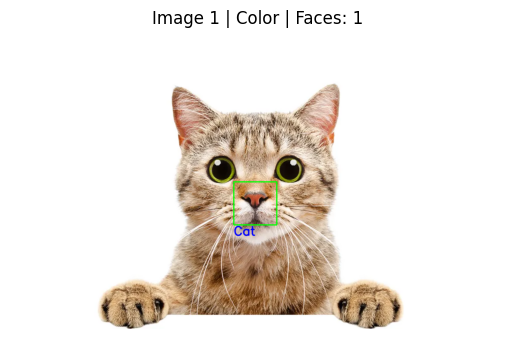

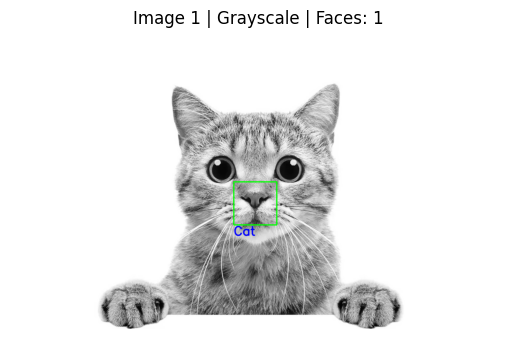

Image 1: Color faces=1, Grayscale faces=1


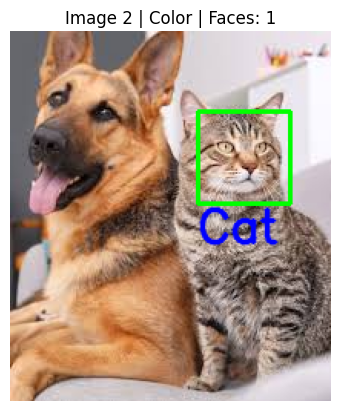

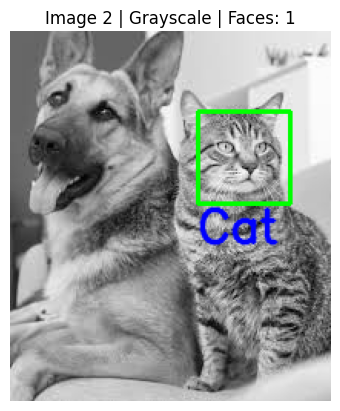

Image 2: Color faces=1, Grayscale faces=1


In [27]:


def detect_and_show_compare(img, cascade, idx):

    faces_color = cascade.detectMultiScale(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), scaleFactor=1.1, minNeighbors=5, minSize=(50, 50))
    img_color = img.copy()
    for (x, y, w, h) in faces_color:
        cv2.rectangle(img_color, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(img_color, 'Cat', (x, y + h + 25), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)
    show_img(img_color, title=f'Image {idx+1} | Color | Faces: {len(faces_color)}')
    

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    faces_gray = cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(50, 50))
    for (x, y, w, h) in faces_gray:
        cv2.rectangle(img_gray, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(img_gray, 'Cat', (x, y + h + 25), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)
    show_img(img_gray, title=f'Image {idx+1} | Grayscale | Faces: {len(faces_gray)}')
    
    print(f'Image {idx+1}: Color faces={len(faces_color)}, Grayscale faces={len(faces_gray)}')

for idx, img in enumerate(images):
    detect_and_show_compare(img, cat_cascade, idx)

# 5.

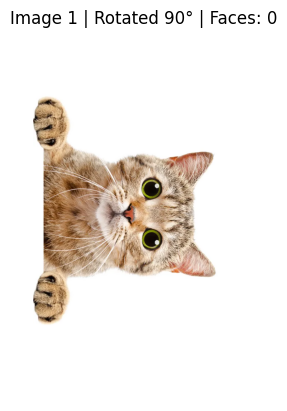

Image 1: no detection on rotation 90°


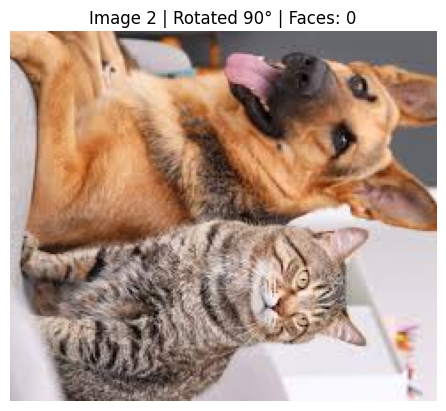

Image 2: no detection on rotation 90°


In [31]:


def detect_rotated_90(img, cascade, idx):
    rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    gray = cv2.cvtColor(rotated, cv2.COLOR_BGR2GRAY)
    faces = cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(50, 50))
    show_img(rotated, title=f'Image {idx+1} | Rotated 90° | Faces: {len(faces)}')
    if len(faces) > 0:
        img_out = rotated.copy()
        for (x, y, w, h) in faces:
            cv2.rectangle(img_out, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(img_out, 'Cat', (x, y + h + 25), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, cv2.LINE_AA)
        show_img(img_out, title=f'Image {idx+1} | Rotated 90° (boxed) | Faces: {len(faces)}')
        print(f'Image {idx+1}: detected on rotation 90° with {len(faces)} face(s)')
    else:
        print(f'Image {idx+1}: no detection on rotation 90°')


for idx, img in enumerate(images):
    detect_rotated_90(img, cat_cascade, idx)

##  Overall Report for Part 1

This section investigated cat face detection using OpenCV and Haar Cascade classifiers on the provided images.

### 1. Image Loading and Display
The notebook first loaded the sample images from the local dataset and displayed them for visual inspection. The original file paths were corrected to match the actual image filenames in the workspace.

### 2. Cat Face Detection
A Haar Cascade classifier (`haarcascade_frontalcatface_extended.xml`) was loaded and applied to the input images. The detected regions were highlighted with green bounding boxes.

### 3. Bounding Box and Label Overlay
In this step, the detected face regions were visualized with rectangles and labeled with the text `Cat` to make the detections easier to interpret.

### 4. Color vs. Grayscale Comparison
The detection performance was compared between the original color images and grayscale versions of the same images. The results were visually inspected and the number of detected faces was printed for each case.

### 5. Rotation Robustness Test
The images were rotated by 90 degrees and the detector was applied again. The rotated versions were displayed, and the notebook reported whether detection was successful.


- The detector successfully found cat faces in the original images.
- In the detection stage, the model mainly localized the central facial region, especially the muzzle and nose area.
- The labeling step worked correctly and made the outputs clearer.
- The grayscale conversion did not significantly change the detection result in the tested examples.
- The rotated images were not detected successfully, which shows that the Haar Cascade used here is not robust to this type of rotation.

### Conclusion
Haar Cascade is suitable for basic cat face detection on the provided images, but it is limited in robustness. It works well on the original images, but it is sensitive to rotation and may localize only part of the face instead of the full head. For more reliable cat detection, a deeper learning-based model would be recommended.

